In [2]:

# 该notebook主要分为用户分群(分别结合CDA2级教材第9章9.4.3层次聚类应用及9.5聚类算法相关内容)
# 导入必备库(结合CDA2级教程相关框架及思路)
import pandas as pd
from sklearn import preprocessing
from sklearn.decomposition import PCA

model_data=pd.read_csv(r"C:\Users\范彬\OneDrive\桌面\train.csv",encoding='gbk')
model_data.head()

# 直接运行出现数据类型不匹配问题报错,故经查询资料进行更改
print(model_data.dtypes)
model_data2=model_data.select_dtypes(include=["number"])#只选择数值类
# 结合CDA2级9.4.3节P256思路,在主成分分析前使用sklearn库的进行变量中心标准化
model_data=preprocessing.scale(model_data2)
# 结合CDA2级7.3.4节P153~P157思路,进行主成分分析
pca=PCA(n_components=5)
newData=pca.fit(model_data)
print(pca.explained_variance_)#显示主成分方差
print(pca.explained_variance_ratio_)#显示主成分方差比
# 由生成结果显示:前3个主成分方差占比大,占比近63%，第一个主成分占比最大,近2.9，前5个主成分总共解释了近83.3%的信息，但系统提醒有较大的极大值影响相关结果.



Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


D:\python 3.14\Lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


[2.89601999 2.04807668 1.99896674 1.21948111 1.00640373]
[0.26327434 0.18618865 0.18172411 0.11086183 0.09149118]


In [3]:
# 结合CDA2级9.4.3节P256~P257思路及框架,用fa_kit框架进行主成分分析和因子分析
# 导入库
from fa_kit import FactorAnalysis
from  fa_kit import plotting as fa_plotting
fa=FactorAnalysis.load_data_samples(
    model_data,preproc_demean=True,preproc_scale=True
)
fa.extract_components()
#设定提取主成分的方式,这里使用CDA2级教程推荐方法"top_n"法
fa.find_comps_to_retain(method="top_n",num_keep=2)
# 补充CDA2级教程相关知识点:因子分析法的优势是通过旋转和拉伸让系数极端化,便于理解各变量重要性
# 通过最大方差法进行因子旋转
fa.rotate_components(method="varimax")
# 查看各因子在在各变量下的权重
pd.DataFrame(fa.comps["rot"])
# 结合CDA2级教程9.4.3层次聚类应用示例思路及框架,可得出相关结论如下:
# 根据前面的主成分分析结果,设置了2个因子,在进行最大方差的因子旋转后称为因子0和因子1
# 显然,原始变量3，4，5，8，9重要性大,具体可分为2种情况:1.因子0权重大，因子1权重小 2.因子1权重大，因子0权重小 具体如下:
# 1.因子0权重大，因子1权重小类型:原始变量3,5,9
# 2.因子1权重大，因子0权重小类型:原始变量4,8


,0,1
0,-0.003649,0.024609
1,-0.038401,-0.071451
2,-0.000472,-0.003563
3,-0.561675,-0.061449
4,-0.004647,0.688508
5,0.583547,-0.034042
6,-0.045855,-0.199150
7,-0.003627,0.024630
8,-0.004773,0.688383
9,0.583389,-0.034048


In [4]:
# 根据CDA2级教程P257指出并加以借鉴修改,对于因子0,主要反映除第二个变量以外的其他变量的信息,所以可以将因子0称为欺诈总量因子,同理根据因子系数的解释,将其命名为Fraud_Avg
# 结合CDA2级教程9.4.3层次聚类应用示例思路及框架,接下来通过这两个因子来展示原始数据的维度,并获得因子得分
# 输出因子得分,为方便拼接,转化 成数据框
fa_scores=fa.get_component_scores(model_data)
fa_scores=pd.DataFrame(fa_scores,columns=["Fraud_Gross","Fraud_Avg"])
fa_scores

,Fraud_Gross,Fraud_Avg
0,1.193841,-0.678521
1,-3.403971,2.850157
2,-2.553094,1.132516
3,-2.077306,2.264818
4,1.495292,-0.003503
...,...,...
1296670,-2.588154,-0.145471
1296671,1.622720,0.316541
1296672,-2.095889,-1.271118
1296673,-1.256405,1.434295


   Fraud_Gross  Fraud_Avg
0    -0.428618   1.858422
1    -0.323225   0.989497
2     1.320529  -1.511466
3     1.880824   1.176806
4    -3.452472   3.031116


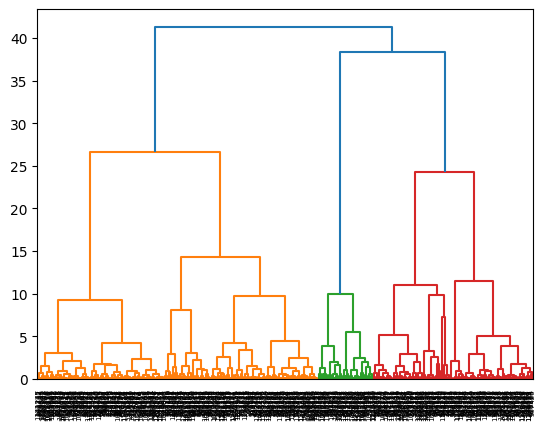

In [15]:
# 结合CDA2级教程9.4.3层次聚类应用示例思路及框架P259，继续使用教程方法中scipy库进行层次聚类
import scipy.cluster.hierarchy as sch
import numpy as np

# #  生成点与点的距离矩阵,这里使用欧式距离
# disMat=sch.distance.pdist(sampled_df[["Fraud_Gross","Fraud_Avg"]],"euclidean")#教程上使用的citi10_fa,这里直接使用fa_scores
# # 进行层次聚类
# F=sch.linkage(disMat,method="ward")
# # 将层次聚类结果用树状图展示出来


# 由于样本集体量较大(超过1000000行),故经过查询资料使用sample抽样法(与02_eda可视化操作相同)
# sampled_df=model_data.sample(n=595,random_state=42)#此处已报错,出现AttributeError,model_data属于numpy数据类型,sample方法仅适用pandas数据类型,查询资料进行优化
# sampled_df=np.random.choice(model_data,size=595,replace=False)#此处再次报错,出现a must be 1-dimensional报错,查询资料进行优化
#再次出现报错,fa_score使用计算体量过大,占用6.12TB,故接下来经过查询资料,先提取出索引,再重新进行抽样
# 生成model_data的索引
indices=np.arange(len(model_data))
# 对索引进行随机抽样
sampled_indices=np.random.choice(indices, size=595, replace=False)
# 根据抽样索引提取
sampled_df=model_data[sampled_indices]

fa_scores2=fa.get_component_scores(sampled_df)
fa_scores2=pd.DataFrame(fa_scores2,columns=["Fraud_Gross","Fraud_Avg"])
print(fa_scores2.head())
# 再次进行尝试,并将fa_score优化成抽样后的fa_score2
disMat=sch.distance.pdist(fa_scores2[["Fraud_Gross","Fraud_Avg"]],"euclidean")
# 进行层次聚类
F=sch.linkage(disMat,method="ward")
#将层次聚类结果用树状图表示出来
P=sch.dendrogram(F,labels=sampled_indices)
